<a href="https://colab.research.google.com/github/IrsyadRazk/BetterSpaceTools/blob/main/ObjectDetectionHuman_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pedestrian Movement Analysis — Google Colab
Run the **same code** as the desktop app, but in the cloud. No local install, no localhost.

**How to use:** click each cell's ▶ play button from top to bottom. For a free GPU (much faster): menu **Runtime → Change runtime type → T4 GPU → Save** before you start.

## 1. Get the code and install YOLO
This clones your GitHub repo and installs Ultralytics YOLO. Takes ~1–2 minutes the first time.

In [ ]:
!git clone https://github.com/IrsyadRazk/ObjectDetectionHuman.git
%cd ObjectDetectionHuman
!pip install -q ultralytics
print("\nDone. Code ready.")

Cloning into 'ObjectDetectionHuman'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 16 (delta 0), reused 16 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 22.51 KiB | 11.25 MiB/s, done.
/content/ObjectDetectionHuman
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.2 MB/s eta 0:00:00

Done. Code ready.


## 2. Upload your video
Click **Choose Files** and pick a short clip (10–20 s is ideal for a first test). Most formats work (MP4, MOV, AVI, MKV, WEBM).

In [ ]:
from google.colab import files
up = files.upload()
video_path = list(up.keys())[0]
print("Uploaded:", video_path)

Saving VIRAT_S_010204_05_000856_000890.mp4 to VIRAT_S_010204_05_000856_000890 (1).mp4
Uploaded: VIRAT_S_010204_05_000856_000890 (1).mp4


## 3. Look at the first frame to read calibration pixel coordinates
The image below has a pixel grid. Hover your mouse over the image to read the (x, y) pixel position shown by Colab, or just estimate from the grid. You need **4 points on the ground** whose real-world distances you know — e.g. corners of a paving slab, or crosswalk stripes.

Renamed '/content/VIRAT_S_010204_05_000856_000890 (1).mp4' to '/content/temp_input_video.mp4' to avoid issues with special characters.
Video: 1280x720 px, 24.0 fps, 584 frames


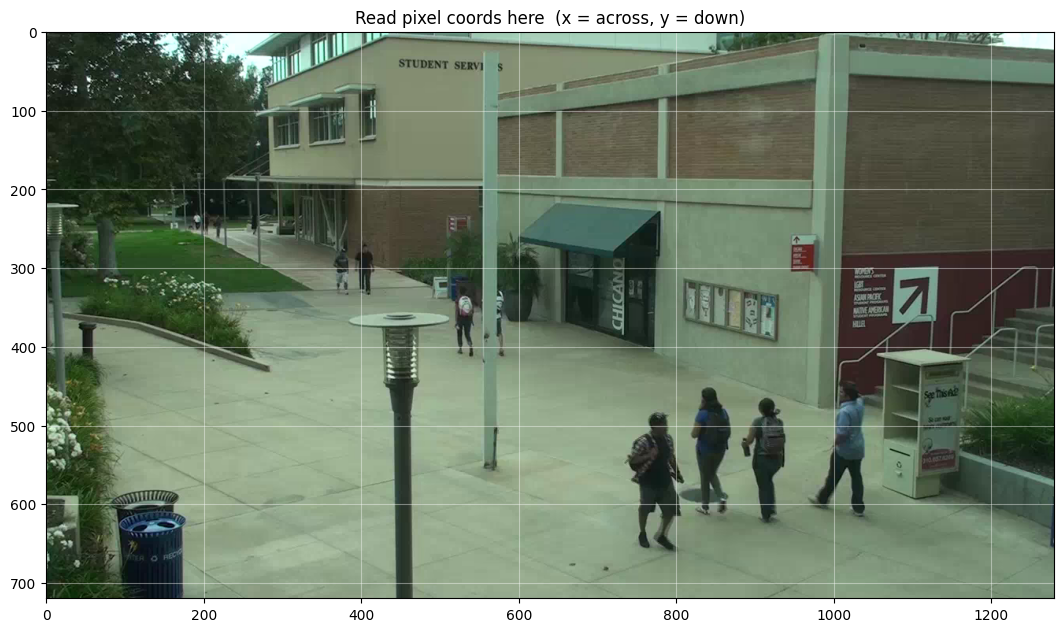

In [ ]:
import cv2, matplotlib.pyplot as plt
from pedestrian_tracker.detector import get_first_frame, read_video_meta
import os

# The `video_path` variable from the previous cell is just the filename.
# files.upload() places files in `/content/`, so we need to construct the full path.
video_path = os.path.join("/content/", video_path) # Make video_path an absolute path

# Rename the video file to a simpler name to avoid potential issues with special characters
# This is common in Colab when files.upload() adds (1), (2) etc.
# Check if the video_path contains problematic characters (spaces or parentheses)
if any(char in video_path for char in [" ", "(", ")"]):
    base_name, ext = os.path.splitext(video_path)
    # Create a new, simpler filename in the same directory (content/)
    temp_video_path = os.path.join(os.path.dirname(video_path), "temp_input_video" + ext)
    if os.path.exists(video_path):
        os.rename(video_path, temp_video_path)
        print(f"Renamed '{video_path}' to '{temp_video_path}' to avoid issues with special characters.")
        video_path = temp_video_path # Update video_path for subsequent uses
    else:
        # This branch should ideally not be hit after making video_path absolute
        print(f"Warning: Original video file '{video_path}' not found, cannot rename.")

frame = get_first_frame(video_path)
meta  = read_video_meta(video_path)
print(f"Video: {meta.width}x{meta.height} px, {meta.fps:.1f} fps, {meta.n_frames} frames")
plt.figure(figsize=(13, 8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Read pixel coords here  (x = across, y = down)")
plt.grid(True, color='white', alpha=0.4)
plt.show()

## 4. Enter your calibration (pixel points → real-world metres)
Edit the two lists below.
- `image_points`: the 4 pixel (x, y) you read from the frame above, **in order**.
- `world_points`: those same 4 spots in real metres. Pick any origin; only the distances between them matter. The example assumes a 3 m × 5 m rectangle.

A reprojection error under ~0.25 m means a good calibration.

In [ ]:
from pedestrian_tracker.calibration import GroundCalibration

image_points = [[420, 880], [1180, 870], [1240, 1040], [360, 1050]]   # <-- EDIT: your pixels
world_points = [[0.0, 0.0], [3.0, 0.0], [3.0, 5.0], [0.0, 5.0]]        # <-- EDIT: metres

calib = GroundCalibration(image_points, world_points)
print(f"Calibration reprojection error: {calib.reprojection_error():.3f} m")

Calibration reprojection error: 0.000 m


## 5. Run the analysis
Auto-uses the GPU if you enabled one. The first run downloads the small YOLO model (~6 MB).

In [ ]:
import torch
from pedestrian_tracker.pipeline import run_pipeline

device = "0" if torch.cuda.is_available() else "cpu"
print("Running on:", "GPU" if device == "0" else "CPU")

result = run_pipeline(
    video_path, calib, output_dir="colab_out",
    weights="yolov8n.pt", conf=0.30, device=device,
    frame_stride=1, smooth_window=5, max_plausible_speed_mps=3.0,
    proximity_threshold_m=1.2, deviation_angle_deg=20.0, window_s=1.0,
    make_video=True, make_heatmap=True,
    progress_cb=lambda i, n: print(f"\rframe {i+1}/{n}", end="") if n else None,
)
print("\nDone. Pedestrians tracked:", result.meta["n_tracks"])

Running on: CPU
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 326ms
Prepared 1 package in 71ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

frame 584/584
Done. Pedestrians tracked: 48


## 6. See the results inline

In [ ]:
speeds = result.trajectories["speed_mps"].dropna()
print(f"Median walking speed: {speeds.median():.2f} m/s")
print(f"Mean walking speed:   {speeds.mean():.2f} m/s")
print(f"Avoidance events:     {(result.avoidance['event_type']=='avoidance').sum()}")
print("\nPer-pedestrian summary:")
display(result.summary)
print("Avoidance / close-pass events:")
display(result.avoidance)

Median walking speed: 0.44 m/s
Mean walking speed:   0.74 m/s
Avoidance events:     43

Per-pedestrian summary:


,track_id,n_frames,duration_s,path_length_m,net_displacement_m,straightness,mean_speed_mps,median_speed_mps,max_speed_mps
0,1,204,8.47,23.42,14.90,0.636,1.003,0.659,2.968
1,2,77,3.21,4.99,3.85,0.771,0.896,0.775,2.930
2,3,261,10.85,22.81,16.01,0.702,1.039,0.793,2.926
3,4,367,15.35,34.72,6.19,0.178,0.990,0.783,2.998
4,5,215,9.60,11.63,5.46,0.469,0.531,0.264,2.996
5,6,148,6.68,12.97,6.99,0.539,0.521,0.193,2.782
6,7,177,7.38,18.77,8.18,0.436,0.660,0.275,2.955
7,8,179,7.59,14.41,2.97,0.206,0.695,0.391,2.913
8,10,1,0.00,0.00,0.00,NaN,NaN,NaN,NaN
9,11,47,2.13,8.38,2.31,0.276,1.363,1.340,2.912


Avoidance / close-pass events:


,id_a,id_b,t_start_s,t_min_s,t_end_s,min_distance_m,dev_a_deg,dev_b_deg,event_type
0,1,3,0.00,0.17,0.25,0.59,14.3,74.6,avoidance
1,1,4,0.00,0.25,0.25,0.84,21.1,73.8,avoidance
2,5,7,0.00,0.38,6.88,0.24,14.2,3.6,close_pass
3,3,4,0.00,0.75,0.79,0.43,32.6,18.5,avoidance
4,1,3,0.75,0.79,0.83,0.66,3.0,46.5,avoidance
5,6,8,0.50,1.17,1.75,0.22,9.4,140.3,avoidance
6,6,8,1.84,1.88,2.34,0.24,55.9,2.0,avoidance
7,6,7,3.21,3.21,3.30,1.08,89.9,8.0,avoidance
8,6,7,3.38,3.38,3.38,1.20,37.9,15.4,avoidance
9,5,8,3.88,3.88,3.88,1.19,26.3,7.0,avoidance


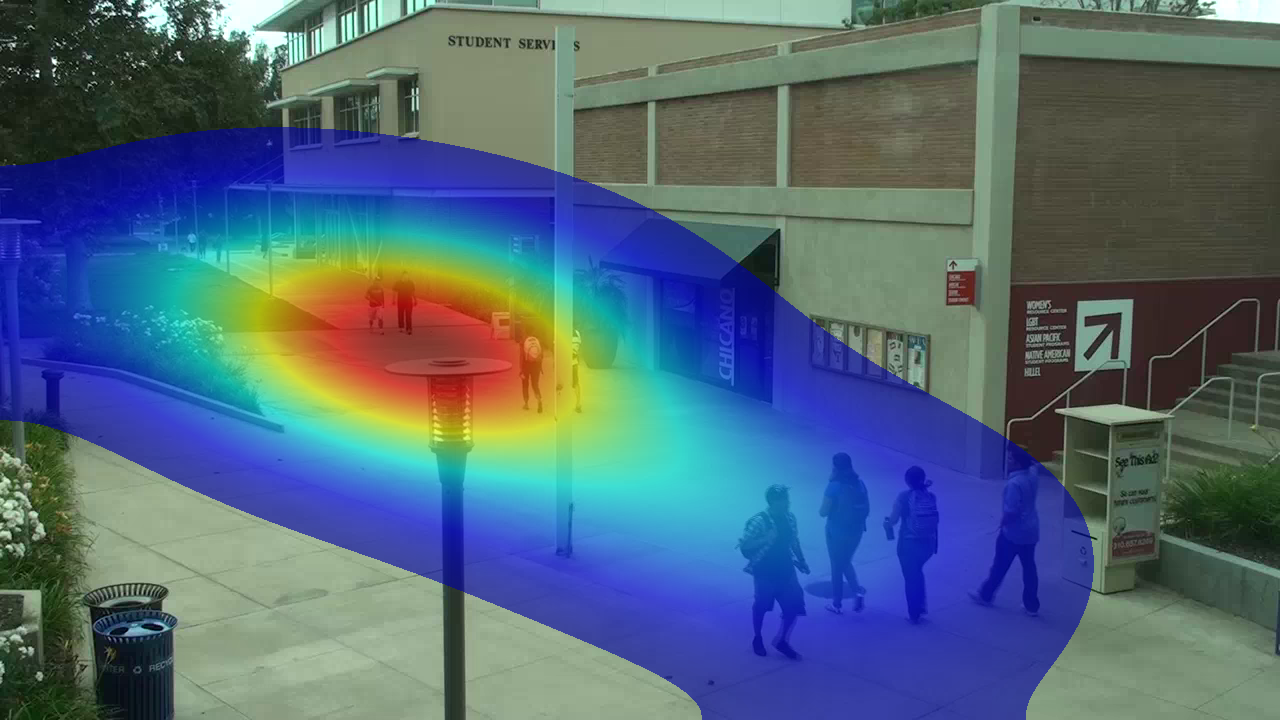

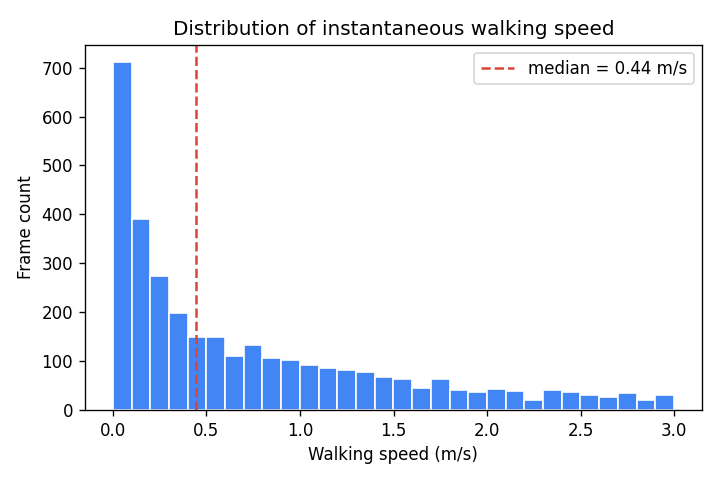

In [ ]:
from IPython.display import Image, display as disp
disp(Image("colab_out/heatmap.png"))
disp(Image("colab_out/speed_distribution.png"))

### Annotated video
Re-encode to a browser-friendly format and play it inline.

In [ ]:
from IPython.display import HTML
from base64 import b64encode
!ffmpeg -y -i colab_out/annotated.mp4 -vcodec libx264 -loglevel quiet colab_out/annotated_h264.mp4
data = b64encode(open("colab_out/annotated_h264.mp4","rb").read()).decode()
HTML(f'<video width=640 controls><source src="data:video/mp4;base64,{data}" type="video/mp4"></video>')

## 7. Download all outputs to your computer

In [ ]:
from google.colab import files
import os
for name in ["trajectories.csv","track_summary.csv","avoidance_events.csv",
             "heatmap.png","speed_distribution.png","annotated_h264.mp4","run_metadata.json"]:
    p = os.path.join("colab_out", name)
    if os.path.exists(p):
        files.download(p)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>